------------

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.


## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import levene
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency


In [3]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [4]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [5]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**: 
 El dataset no tiene valores ausentes.

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [6]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [7]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [8]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [9]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [10]:
# Resumen estadístico de usuarios que se convirtieron
df["converted"].value_counts(normalize=True)

0    0.85735
1    0.14265
Name: converted, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [11]:
# Explorar variables categóricas y cómo se distribuyen
categoricas = ['landing','region','dispositivo','traffic_source','user_type','converted']
for col in categoricas:
    print("\nConteo de categorías:")
    print(df[col].value_counts(normalize=True)) #completa el código)


Conteo de categorías:
B    0.50045
A    0.49955
Name: landing, dtype: float64

Conteo de categorías:
Norte        0.279150
Centro       0.240325
Sur          0.200975
Occidente    0.159950
Oriente      0.119600
Name: region, dtype: float64

Conteo de categorías:
Mobile     0.620725
Desktop    0.379275
Name: dispositivo, dtype: float64

Conteo de categorías:
Organic     0.449675
Ads         0.298375
Email       0.153075
Referral    0.098875
Name: traffic_source, dtype: float64

Conteo de categorías:
Nuevo         0.650825
Recurrente    0.349175
Name: user_type, dtype: float64

Conteo de categorías:
0    0.85735
1    0.14265
Name: converted, dtype: float64


✍️ **Comentario**: 
    - Todas las columnas tienen valores esperados.
    
    - La distribución de A y B es muy cercana
    
    - La región Norte tiene mayor presencia y Oriente la menor
    
    - El dispositivo movil es el que se utilizó en la mayoría de los ingresos
    
    - El canal que mayores ingresos reporta es 'organic'
    
    - El tipo de usuario con más reporte son los nuevos


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [12]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto'] #completa el código
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto'] #completa el código
print(f"gasto A: {len(gasto_A)}")
print(f"gasto B: {len(gasto_B)}")
# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

print(f"Gasto promedio A: {gasto_A.mean()}")
print(f"Gasto promedio B: {gasto_B.mean()}")

gasto A: 2512
gasto B: 3194
Gasto promedio A: 61.0865724522293
Gasto promedio B: 68.74536005009392


### Prueba t

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto en ambas versiones de las páginas no es diferente
- **Hipótesis alternativa (H₁):** El gasto en una versión de la página es mayor

In [20]:
levene_stat, levene_p = levene(gasto_A, gasto_B)
print(f"Levene - Estadístico: {levene_stat}")
print(f"Levene - Valor p: {levene_p}")

Levene - Estadístico: 29.17646453202917
Levene - Valor p: 6.875301988016449e-08


In [21]:
if levene_p > 0.05:
    t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=True)
    print("Usando t-test con varianzas iguales")
else:
    t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)
    print("Usando Welch's t-test (varianzas desiguales)")

Usando Welch's t-test (varianzas desiguales)


In [22]:
alpha = 0.05
print(f"\nResultados del t-test:")
print(f"Estadístico t: {t_stat}")
print(f"Valor p: {p_value}")

if p_value < alpha:
    print(f"✅ DECISIÓN: Rechazamos H₀ (p = {p_value:.4f} < {alpha})")
    print("La diferencia en gasto promedio ES estadísticamente significativa")
    print("Conclusión: La página B genera significativamente más gasto por usuario")
else:
    print(f"❌ DECISIÓN: No rechazamos H₀ (p = {p_value:.4f} ≥ {alpha})")
    print("La diferencia podría deberse al azar")
    print("Conclusión: No hay evidencia suficiente de diferencia real")


Resultados del t-test:
Estadístico t: -9.48101092267275
Valor p: 3.627602231521493e-21
✅ DECISIÓN: Rechazamos H₀ (p = 0.0000 < 0.05)
La diferencia en gasto promedio ES estadísticamente significativa
Conclusión: La página B genera significativamente más gasto por usuario


In [23]:
stat_levene, p_levene = levene(gasto_A, gasto_B)

if p_levene > 0.05:
    stat_t, p_t = ttest_ind(gasto_A, gasto_B, equal_var=True)
else:
    stat_t, p_t = ttest_ind(gasto_A, gasto_B, equal_var=False)

In [27]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)
# Visualizar resultados
print(f"Estadístico t: {t_stat}")
print(f"Valor p: {p_value}")

Estadístico t: -9.48101092267275
Valor p: 3.627602231521493e-21


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula

**Interpretación de negocio:**  
Existe una diferencia significativa basada en estadísitica de que hay diferencia en el gasto promedio entre las dos versiones, la págiana B genera más gasto promedio.


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z
**Hipótesis:**
- **Hipótesis nula (H₀):** Los usuarios que convierten en ambas páginas no cambia.
- **Hipótesis alternativa (H₁):** Los usuarios que convierten son diferentes en cada página.

In [28]:
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [32]:
conversion_summary = df.groupby('landing')['converted'].agg(['count', 'sum']).reset_index()
conversion_summary.columns = ['landing', 'total_users', 'conversions']

# Calcular tasa de conversión
conversion_summary['conversion_rate'] = conversion_summary['conversions'] / conversion_summary['total_users']

print("TASAS DE CONVERSIÓN POR VERSIÓN:")
for _, row in conversion_summary.iterrows():
    rate = row['conversion_rate'] * 100
    print(f"Página {row['landing']}: {rate:.2f}% ({row['conversions']}/{row['total_users']})")


TASAS DE CONVERSIÓN POR VERSIÓN:
Página A: 12.57% (2512/19982)
Página B: 15.96% (3194/20018)


In [33]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(conversiones , totales)

# Visualizar resultados
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

Estadístico z: -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula

**Interpretación de negocio:**  
Hay evidencia estadísitica que indica que la tasa de conversión de la versión B es más alta que la tasa de conversión de la versión A

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi-cuadrada
**Hipótesis:**
- **Hipótesis nula (H₀):** La fuente de tráfico no interviene en la conversión de usuarios.
- **Hipótesis alternativa (H₁):** La fuente de tráfico interviene en la conversión de usuarios.

In [44]:
contingency_table = pd.crosstab(df['traffic_source'], df['converted'])
print('Tabla de Contingencia:')
print(contingency_table)

Tabla de Contingencia:
converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [45]:
df[['traffic_source','converted']].value_counts()

traffic_source  converted
Organic         0            15507
Ads             0            10176
Email           0             5205
Referral        0             3406
Organic         1             2480
Ads             1             1759
Email           1              918
Referral        1              549
dtype: int64

In [47]:
# Aplicar prueba
chi2_contingency(contingency_table)

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


In [48]:
conversion_rates = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
print("Tasas de conversión por fuente:")
print(conversion_rates[1]) 

Tasas de conversión por fuente:
traffic_source
Ads         14.738165
Email       14.992651
Organic     13.787736
Referral    13.881163
Name: 1, dtype: float64


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula

**Interpretación de negocio:**  
La fuente de tráfico no interviene de forma significativa en la conversión de usuarios, los canales convierten entre un 13.8% y 15% lo que es similar.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi-cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** El tipo de usuario no influye en la conversión.
- **Hipótesis alternativa (H₁):** El tipo de usuario si influye en la conversión.

In [49]:
tabla = pd.crosstab(df['user_type'], df['converted'])
tabla

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [50]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"Estadístico chi-cuadrado: {chi2_stat}")
print(f"Valor P: {p_value}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

Estadístico chi-cuadrado: 0.5134849494478645
Valor P: 0.4736341272301974
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula

**Interpretación de negocio:**  
No existe evidencia estadística que indique que el tipo de usuario influye en la conversión, no se puede justificar estrategias diferentes para usuarios nuevos y recurrentes

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

In [53]:
tabla = pd.crosstab(df['traffic_source'], df['converted'])
tabla

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


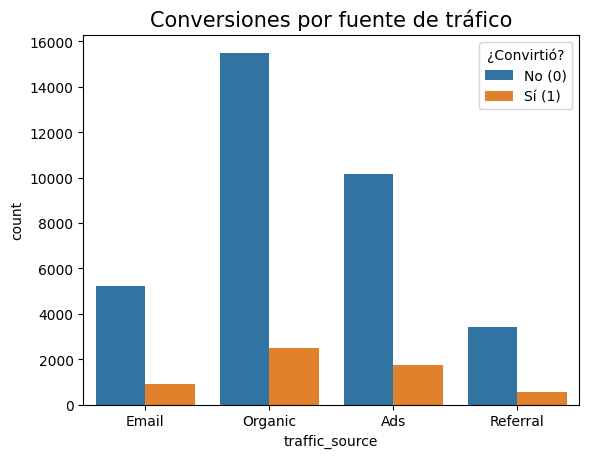

In [54]:
sns.countplot(data=df, x='traffic_source', hue='converted')

plt.title('Conversiones por fuente de tráfico', fontsize=15)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])

plt.show()

✍️ **Comentario**: En el gráfico se observa la relación de la fuente de tráfico y la cantidad de usuarios que convirtieron en cada una de ellas, se observa que quienes llegaron de manera orgánica convitieron más y los referidos fueron quienes convirtieron menos, también se observa que los que llegaron de forma orgánica son más los que no convirtieron y los referidos los que menos no convirtieron

### Relación entre el tipo de usuario y la conversión

In [56]:
tabla = pd.crosstab(df['user_type'], df['converted'])
tabla

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


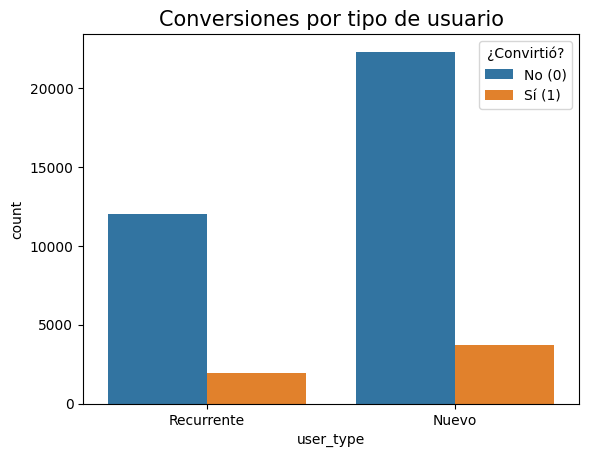

In [57]:
sns.countplot(data=df, x='user_type', hue='converted')
plt.title('Conversiones por tipo de usuario', fontsize=15)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario**: En el gráfico obervamos la relaicón del tipo de usuario (nuevo y recurrente) con la conversión, se observa que los usuarios nuevos son los que más convierten pero también la cantidad de usuarios nuevos que no convierten es alta.

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Existe una diferencia entre el gasto en ambos grupos 
- Hay evidencia estadística de que hay diferencia de 12.5% más en el gasto de la versión B
- **Interpretación:**
La página B genera $7.66 más por usuario convertido
<br>

**Tasa de conversión:** 
- La diferencia de conversión es significativa, Página A: 12.57% Página B: 15.95%
- Hay evidencia estadística que indica que la tasa de conversión de la versión B es más alta que la tasa de conversión de la versión A
- **Interpretación:**
Los usuarios que convierten en la versión B es mayor en un 3%


#### 📊 **Segmentación por fuente de tráfico**
- Los usuarios que llegan de desde el correo electrónico son los que tienen mayor tasa de conversión, y los usuarios que llegan de forma orgánica tienen menor tasa de conversión
- **Interpretación:**
La fuente de tráfico no interviene de forma significativa en la conversión de usuarios, los canales convierten entre un 13.8% y 15% lo que es similar.
 

#### 📊 **Segmentación por tipo de usuario**
- La cantidad de usuarios nuevos que convierten es más alta que los usuarios recurrentes que convierten
- En los usuarios nuevos hay más cantidad que no convierten
- Hay más usuarios nuevos que recurrentes
- **Interpretación:**
No existe evidencia estadística que indique que el tipo de usuario influye en la conversión, no se puede justificar estrategias diferentes para usuarios nuevos y recurrentes


Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
-  Se recomienda un análisis sobre la relación de tipo de usuario en cada página y su conversión
-  Se recomienda para el equipo de marketing implementar estrategias para los usuarios recurrentes